In [9]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from Log_Extractor import LogExtractor
from pump_config import PUMP_TO_TANK
import joblib
from sklearn.ensemble import RandomForestRegressor
from Pump_Preprocess import RealTimePreprocessor
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from Pump_AE import PumpAutoencoder
import os

In [10]:
### 원하는 펌프 입력해라.
PUMP_ID = "P1"
MODEL_DIR = "anomaly_models"
MODEL_STRUCTURE_DIR = "models_structures"

pump_info = PUMP_TO_TANK.get(PUMP_ID, None)
TANK_ID = pump_info['Tank'] if pump_info else None
ROBOT_ID = pump_info['Robot'] if pump_info else None

target_tags = [
            f'Pump_BuildUp_{PUMP_ID}' , f'{ROBOT_ID}_Robot_Num', 
            f'g_s_SV_{PUMP_ID}', f'Ana_Out_{PUMP_ID}', 
            f'Scale_Out___PT_{PUMP_ID}', f'Scale_Out___FT_{PUMP_ID}', 
            f'TK_Temp_PV_{TANK_ID}', f'TK_Level_PV_{TANK_ID}'
        ]

feature_cols = [
                f'g_s_SV_{PUMP_ID}', 'Prev_SV', 'Prev_SV_Diff', 
                f'Ana_Out_{PUMP_ID}', f'TK_Temp_PV_{TANK_ID}',               
                f'Scale_Out___PT_{PUMP_ID}', 'Rolling_PT_Max_3', 'Rolling_PT_Diff_3', 
                f'Scale_Out___FT_{PUMP_ID}', 'Instant_FT_Error_Rate', 'Cum_FT_Error',  
                'Phase_Start', 'Phase_Steady', 'Phase_Transition'             
            ]

In [3]:
extract = LogExtractor()
start_time="2026-04-22T02:00:00Z"
end_time="2026-04-22T03:05:00Z"

🔌 [Extractor] InfluxDB 분석용 추출기 연결 완료!


In [11]:
PUMP_ID = 'P1' # 나중에 P2, P3 등으로 변경

model = PumpAutoencoder(input_dim=len(feature_cols))
model.load_state_dict(torch.load(f'{MODEL_DIR}/autoencoder_{PUMP_ID}.pth', weights_only=True))
model.eval() # 추론 모드

scaler = joblib.load(f'{MODEL_DIR}/scaler_{PUMP_ID}.pkl')


In [5]:
test_df = extract.get_data(start_time=start_time, end_time=end_time, target_tags=target_tags)

🚀 전체 구간 데이터 추출 시작: 2026-04-22T02:00:00+00:00 ~ 2026-04-22T03:05:00+00:00
📦 [Chunk] 2026-04-22T02:00:00Z ~ 2026-04-22T03:05:00Z 요청 중...
✅ 전체 데이터 통합 완료! 총 1681행 확보.


## 별로 안정밀한거

In [12]:
from Pump_Preprocess import RealTimePreprocessor
# 1. 전처리기 객체 생성 (학습할 때 만들었던 scaler와 feature_cols를 넣어줍니다)
preprocessor = RealTimePreprocessor(
    scaler=scaler, 
    feature_cols=feature_cols, 
    pump_id=PUMP_ID, 
    tank_id=TANK_ID, 
    robot_id=ROBOT_ID
)

# 결과를 담을 빈 리스트
inference_results = []
# 2. 실시간 시뮬레이션
# raw_df는 추출기에서 가져온 아무 가공도 안 된 쌩(Raw) 데이터프레임입니다.
print("📡 실시간 데이터 스트리밍 시작...")

for i in range(len(test_df)):
    raw_tick = test_df.iloc[i] # 진짜 딱 1줄씩 가져옴
    
    # [노이즈 필터링] 안 쏘거나 정지 중인 데이터는 스킵 (실시간 판단)
    if raw_tick[f'Pump_BuildUp_{PUMP_ID}'] != 1:
        continue
        
    # ------------------------------------------------
    # 🎩 마법의 전처리기 통과!
    # ------------------------------------------------
    tensor_data, df_processed, meta_info = preprocessor.process_raw_tick(raw_tick)
    
    # ------------------------------------------------
    # 🤖 모델 추론
    # ------------------------------------------------
    model.eval()
    with torch.no_grad():
        reconstructed = model(tensor_data)
        mse_loss = torch.mean((tensor_data - reconstructed) ** 2).item()
        feature_errors = torch.abs(tensor_data - reconstructed).numpy()[0]
    
    # ★ 결과 저장 (그래프를 그리기 위해 핵심 데이터만 모읍니다)
    inference_results.append({
        'Time': raw_tick.name, # 이 부분이 꼭 있어야 X축으로 쓸 수 있습니다!
        'Wagon_Num': meta_info['Wagon_Num'],
        'Tick_Index': meta_info['Tick_Index'],
        'Loss': mse_loss,
        'Target_SV': df_processed[f'g_s_SV_{PUMP_ID}'].values[0],
        'Actual_FT': df_processed[f'Scale_Out___FT_{PUMP_ID}'].values[0],
        'Actual_PT': df_processed[f'Scale_Out___PT_{PUMP_ID}'].values[0]
    })
    
    # 리스트를 데이터프레임으로 변환
    results_df = pd.DataFrame(inference_results)
    print(f"✅ 총 {len(results_df)}틱의 추론 결과 수집 완료!")
    
    # 테스트를 위해 일정량 수집 후 종료 (필요시 조절)
    if len(inference_results) >= 50000:
        break

# 결과 확인
results_df = pd.DataFrame(inference_results)
print(f"✅ 총 {len(results_df)}틱의 추론 완료!")
print(results_df.tail(10))

📡 실시간 데이터 스트리밍 시작...
✅ 총 1틱의 추론 결과 수집 완료!
✅ 총 2틱의 추론 결과 수집 완료!
✅ 총 3틱의 추론 결과 수집 완료!
✅ 총 4틱의 추론 결과 수집 완료!
✅ 총 5틱의 추론 결과 수집 완료!
✅ 총 6틱의 추론 결과 수집 완료!
✅ 총 7틱의 추론 결과 수집 완료!
✅ 총 8틱의 추론 결과 수집 완료!
✅ 총 9틱의 추론 결과 수집 완료!
✅ 총 10틱의 추론 결과 수집 완료!
✅ 총 11틱의 추론 결과 수집 완료!
✅ 총 12틱의 추론 결과 수집 완료!
✅ 총 13틱의 추론 결과 수집 완료!
✅ 총 14틱의 추론 결과 수집 완료!
✅ 총 15틱의 추론 결과 수집 완료!
✅ 총 16틱의 추론 결과 수집 완료!
✅ 총 17틱의 추론 결과 수집 완료!
✅ 총 18틱의 추론 결과 수집 완료!
✅ 총 19틱의 추론 결과 수집 완료!
✅ 총 20틱의 추론 결과 수집 완료!
✅ 총 21틱의 추론 결과 수집 완료!
✅ 총 22틱의 추론 결과 수집 완료!
✅ 총 23틱의 추론 결과 수집 완료!
✅ 총 24틱의 추론 결과 수집 완료!
✅ 총 25틱의 추론 결과 수집 완료!
✅ 총 26틱의 추론 결과 수집 완료!
✅ 총 27틱의 추론 결과 수집 완료!
✅ 총 28틱의 추론 결과 수집 완료!
✅ 총 29틱의 추론 결과 수집 완료!
✅ 총 30틱의 추론 결과 수집 완료!
✅ 총 31틱의 추론 결과 수집 완료!
✅ 총 32틱의 추론 결과 수집 완료!
✅ 총 33틱의 추론 결과 수집 완료!
✅ 총 34틱의 추론 결과 수집 완료!
✅ 총 35틱의 추론 결과 수집 완료!
✅ 총 36틱의 추론 결과 수집 완료!
✅ 총 37틱의 추론 결과 수집 완료!
✅ 총 38틱의 추론 결과 수집 완료!
✅ 총 39틱의 추론 결과 수집 완료!
✅ 총 40틱의 추론 결과 수집 완료!
✅ 총 41틱의 추론 결과 수집 완료!
✅ 총 42틱의 추론 결과 수집 완료!
✅ 총 43틱의 추론 결과 수집 완료!
✅ 총 44틱의 추론 결과 수집 완료!
✅ 총 45틱의 추론 결과 수집 완료

## 정밀한거

In [7]:
from Detect_Anomaly import detect_anomaly, identify_culprit, extract_context_data
# 1. 설정값 세팅
THRESHOLD = 4  
LOOKBACK = 5     

realtime_buffer = [] 

print(f"🚀 [시스템 가동] 임계치 {THRESHOLD} 기반 실시간 감시 및 정밀 분석 시작...")
print("=" * 80)

anomaly_count = 0

for i in range(len(test_df)):
    raw_tick = test_df.iloc[i]
    
    # ⏱️ 핵심: 현재 데이터의 시간(Timestamp) 가져오기
    # 보통 InfluxDB에서 가져온 데이터프레임은 인덱스(name)가 시간입니다.
    current_time = raw_tick.name 
    
    # [필터링] 가동 중일 때만 분석
    # [필터링] 빌드업 신호가 있을 때만 분석 수행 (앞서 합의한 규칙)
    if raw_tick[f'Pump_BuildUp_{PUMP_ID}'] != 1:
        continue
        
    # 1. 전처리 통과
    tensor_data, df_processed, meta_info = preprocessor.process_raw_tick(raw_tick)

    # [추가된 로직] 현재 샷이 '콜드 스타트'인지 확인
    is_cold_start = False
    
    # 현재 버퍼에 이전 샷 기록이 있고, 현재 틱이 샷의 극초반(예: 0~2틱)일 때만 검사
    if len(realtime_buffer) > 0 and meta_info['Tick_Index'] <= 2:
        last_shot_time = realtime_buffer[-1]['Time'].iloc[0]
        current_time = raw_tick.name
        
        # 직전 데이터와 현재 데이터의 시간 차이가 3분(180초) 이상이면 콜드 스타트로 간주
        time_diff = (current_time - last_shot_time).total_seconds()
        if time_diff > 10:
            is_cold_start = True
    
    # 분석을 위해 버퍼에 저장할 때 시간 정보도 같이 넣습니다.
    current_record = df_processed.copy()
    current_record['Time'] = current_time  # 시간 컬럼 추가!
    current_record['Wagon_Num'] = meta_info['Wagon_Num']
    current_record['Tick_Index'] = meta_info['Tick_Index']
    realtime_buffer.append(current_record)
    
    # 2. 실시간 이상 탐지
    mse_score, feature_errors = detect_anomaly(model, scaler, df_processed, feature_cols)
    
    # 3. 이상 발생 시 정밀 진단
    if mse_score > THRESHOLD:
        if is_cold_start:
            # 점수가 높아도 알람을 울리지 않고 넘어갑니다. (로그만 가볍게 남김)
            # print(f"🕒 [콜드 스타트 무시] 3분 이상 대기 후 첫 가동이라 알람을 생략합니다. (Time: {current_time})")
            continue
        anomaly_count += 1
        
        culprits = identify_culprit(feature_errors, feature_cols, top_k=3)
        
        buffer_df = pd.concat(realtime_buffer)
        context_df = extract_context_data(buffer_df, len(buffer_df)-1, lookback=LOOKBACK)
        
        # ------------------------------------------------
        # 📋 정밀 분석 리포트 출력 (시간 추가됨!)
        # ------------------------------------------------
        print(f"🚨 [ANOMALY DETECTED #{anomaly_count}]")
        # 보기 좋게 시간을 문자열 형식(YYYY-MM-DD HH:MM:SS)으로 출력
        formatted_time = current_time.strftime('%Y-%m-%d %H:%M:%S') if hasattr(current_time, 'strftime') else current_time
        print(f"⏰ 발생 시간: {formatted_time}")
        print(f"📍 발생 위치: 대차 번호 {meta_info['Wagon_Num']} | 샷 내 위치: {meta_info['Tick_Index']} 틱")
        print(f"📈 이상 점수(MSE): {mse_score:.4f} (위험 수준)")
        
        print(f"🕵️‍♂️ 범인 색출 결과 (Top 3 기여도):")
        for idx, row in culprits.iterrows():
            print(f"   - [{row['Feature']}] : {row['Error_Contribution(%)']:.1f}% 지분")
            
        print(f"📦 상황(Context) 데이터 (최근 {len(context_df)}틱 흐름):")
        # 상황 데이터 출력할 때도 시간(Time)을 맨 앞에 보여줍니다.
        display_cols = ['Time', 'Tick_Index', f'g_s_SV_{PUMP_ID}', f'Scale_Out___PT_{PUMP_ID}', f'Scale_Out___FT_{PUMP_ID}', 'Instant_FT_Error_Rate']
        print(context_df[display_cols].to_string(index=False))
        
        print("-" * 80)
        
        if anomaly_count >= 500: # 이번엔 5개까지 넉넉하게 뽑아봅시다
            print("💡 초기 분석을 위해 5개의 케이스만 추출했습니다. 루프를 종료합니다.")
            break

if anomaly_count == 0:
    print("✅ 현재 데이터 구간에서는 임계치를 넘는 이상 징후가 발견되지 않았습니다.")

🚀 [시스템 가동] 임계치 4 기반 실시간 감시 및 정밀 분석 시작...
✅ 현재 데이터 구간에서는 임계치를 넘는 이상 징후가 발견되지 않았습니다.


/var/folders/fj/zp006l253zsg23q736jqrh800000gn/T/ipykernel_23963/159098156.py:62: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) AppleGothic.
  plt.tight_layout()
/var/folders/fj/zp006l253zsg23q736jqrh800000gn/T/ipykernel_23963/159098156.py:62: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) AppleGothic.
  plt.tight_layout()
/Users/jeonjae/Desktop/KTA/DB_Log/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeonjae/Desktop/KTA/DB_Log/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


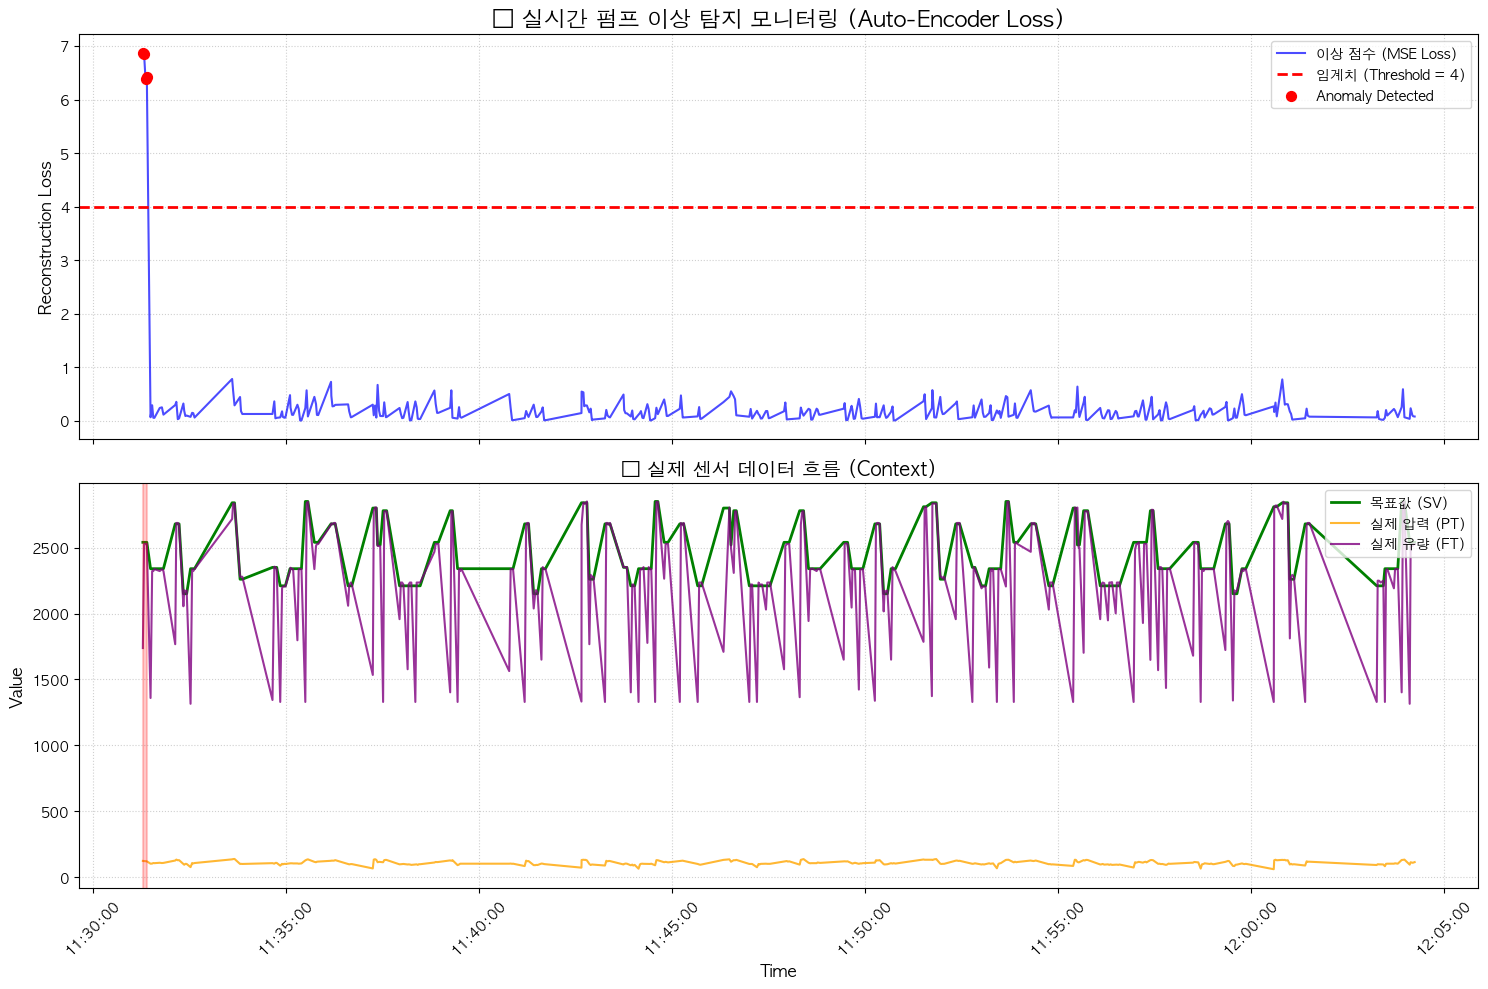

In [8]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# 한글 폰트 설정 (폰트 깨짐 방지 - 환경에 맞게 수정 필요)
plt.rcParams['font.family'] = 'AppleGothic' # Windows
# plt.rcParams['font.family'] = 'AppleGothic' # Mac
plt.rcParams['axes.unicode_minus'] = False

def plot_anomaly_results(results_df, threshold=0.5):
    """
    AE 이상 탐지 결과를 시각화합니다.
    Top: 시간(X축)에 따른 이상 점수(Loss)와 임계치(Threshold)
    Bottom: 시간(X축)에 따른 SV(목표 압력), PT(실제 압력), FT(유량) 변화
    """
    # Time 컬럼을 datetime 형식으로 변환 (인덱스가 아닌 경우 대비)
    if not pd.api.types.is_datetime64_any_dtype(results_df['Time']):
        results_df['Time'] = pd.to_datetime(results_df['Time'])
        
    # 이상치(Anomaly)만 따로 필터링
    anomalies = results_df[results_df['Loss'] > threshold]

    # 그래프 레이아웃 설정 (위아래 2칸)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

    # -----------------------------------------------------------
    # [Top 그래프] 이상 점수 (Reconstruction Loss) 모니터링
    # -----------------------------------------------------------
    ax1.plot(results_df['Time'], results_df['Loss'], color='blue', alpha=0.7, label='이상 점수 (MSE Loss)')
    ax1.axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'임계치 (Threshold = {threshold})')
    
    # 임계치를 넘은 구간 빨간색 점으로 강조
    if not anomalies.empty:
        ax1.scatter(anomalies['Time'], anomalies['Loss'], color='red', s=50, zorder=5, label='Anomaly Detected')
        
    ax1.set_title("🚀 실시간 펌프 이상 탐지 모니터링 (Auto-Encoder Loss)", fontsize=16, fontweight='bold')
    ax1.set_ylabel("Reconstruction Loss", fontsize=12)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(loc='upper right')

    # -----------------------------------------------------------
    # [Bottom 그래프] 원본 시계열 데이터 흐름 (SV, PT, FT)
    # -----------------------------------------------------------
    ax2.plot(results_df['Time'], results_df['Target_SV'], color='green', linestyle='-', linewidth=2, label='목표값 (SV)')
    ax2.plot(results_df['Time'], results_df['Actual_PT'], color='orange', linestyle='-', alpha=0.8, label='실제 압력 (PT)')
    ax2.plot(results_df['Time'], results_df['Actual_FT'], color='purple', linestyle='-', alpha=0.8, label='실제 유량 (FT)')

    # 아래쪽 그래프에도 이상 구간을 연한 빨간색 세로 배경으로 표시
    for anomaly_time in anomalies['Time']:
        ax2.axvline(x=anomaly_time, color='red', alpha=0.2, linestyle='-')

    ax2.set_title("📈 실제 센서 데이터 흐름 (Context)", fontsize=14)
    ax2.set_xlabel("Time", fontsize=12)
    ax2.set_ylabel("Value", fontsize=12)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(loc='upper right')

    # X축 시간 포맷팅 (HH:MM:SS 형태로 깔끔하게)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

# 함수 실행!
plot_anomaly_results(results_df, threshold=THRESHOLD)